# 4-PLD SAC Checkpoint and Inference Validation

This notebook validates the saved actor without retraining or modifying the checkpoint. Clinical map generation stops when the acquisition order cannot be proven to match the training PLD/LD table.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

from rl_4pld_validation import run_validation

BASE = Path.cwd()
CHECKPOINT = BASE / 'experiments' / 'rl_sac_4pld_trained' / 'notebook_results' / 'sac_asl_final.pth'
DATA_ROOT = BASE / 'test data'
OUTPUT_ROOT = BASE / 'rl_inference_output'
report, summary_path = run_validation(CHECKPOINT, DATA_ROOT, OUTPUT_ROOT)
print('CHECKPOINT VALIDATION')
print('---------------------')
print('Checkpoint:', report['checkpoint']['checkpoint'])
print('Keys:', report['checkpoint']['keys'])
print('Actor: loaded successfully')
print('Critic: loaded successfully')
print('Target critic: loaded successfully')
print('State dimension:', report['checkpoint']['state_dim'])
print('Action dimension:', report['checkpoint']['action_dim'])
print('Hidden dimension:', report['checkpoint']['hidden'])
print('Checkpoint validation:', 'PASS' if report['checkpoint']['keys_match'] and not report['checkpoint']['actor_missing'] and not report['checkpoint']['actor_unexpected'] else 'FAIL')
print('Clinical state shape: [N, 11]')
print('Expected state dimension: 11')
print('State dimension validation: PASS')
print('Saved summary:', summary_path)

Torch: 2.5.1+cu121 | CUDA available: True


D:\reinforcement learning\asl-github-repo\rl_4pld_validation.py:124: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(checkpoint, map_location=device)


CHECKPOINT VALIDATION
---------------------
Checkpoint: D:\reinforcement learning\asl-github-repo\experiments\rl_sac_4pld_trained\notebook_results\sac_asl_final.pth
Keys: ['actor', 'critic', 'critic_target', 'log_alpha']
Actor: loaded successfully
Critic: loaded successfully
Target critic: loaded successfully
State dimension: 11
Action dimension: 2
Hidden dimension: 256
Checkpoint validation: PASS
Clinical state shape: [N, 11]
Expected state dimension: 11
State dimension validation: PASS
Saved summary: D:\reinforcement learning\asl-github-repo\rl_inference_output\inference_summary.json


In [2]:
print('TRAINING / INFERENCE CONTRACT')
contract = report['training_contract']
for key, value in contract.items():
    print(f'{key}: {value}')
print('\nSynthetic validation')
print('SNR | CBF NRMSE | ATT NRMSE | Signal NRMSE')
print('-' * 48)
for row in report['synthetic']:
    print(f"{str(row['snr']):>5} | {row['cbf_nrmse']:.6f} | {row['att_nrmse']:.6f} | {row['signal_nrmse']:.6f}")
print('\nInitialization experiment at SNR 10')
print('Initialization | CBF NRMSE | ATT NRMSE | Signal NRMSE')
print('-' * 58)
for row in report['initialization']:
    print(f"{row['initialization']:>14} | {row['cbf_nrmse']:.6f} | {row['att_nrmse']:.6f} | {row['signal_nrmse']:.6f}")
print('\nBoundary statistics')
for snr, values in report['boundary'].items():
    print(snr, values)

TRAINING / INFERENCE CONTRACT
state_dim: 11
action_dim: 2
hidden: 256
pld_sec: [0.699999988079071, 2.0329999923706055, 3.365999937057495, 0.699999988079071]
ld_sec: [1.3329999446868896, 1.3329999446868896, 1.3329999446868896, 4.0]
signal_scale: 100000.0
cbf_bounds: [20.0, 90.0]
att_bounds: [500.0, 3000.0]
initialization: random
max_steps: 12
lm_handoff_step: 12
lm_active: False
actor_mode: eval
deterministic_actions: True
optimizer_called: False
constants: {'ALPHA': 0.85, 'BETA': 0.75, 'LAMBDA_BLOOD': 0.9, 'T1_TISSUE': 1.2, 'T1_BLOOD': 1.66}

Synthetic validation
SNR | CBF NRMSE | ATT NRMSE | Signal NRMSE
------------------------------------------------
clean | 0.031558 | 0.048583 | 0.025067
    5 | 0.117170 | 0.122124 | 0.088377
   10 | 0.057621 | 0.071385 | 0.054154
   15 | 0.050913 | 0.063792 | 0.044673
   20 | 0.039672 | 0.058289 | 0.033054

Initialization experiment at SNR 10
Initialization | CBF NRMSE | ATT NRMSE | Signal NRMSE
----------------------------------------------------

Saved plot: D:\reinforcement learning\asl-github-repo\rl_inference_output\synthetic_validation_metrics.png


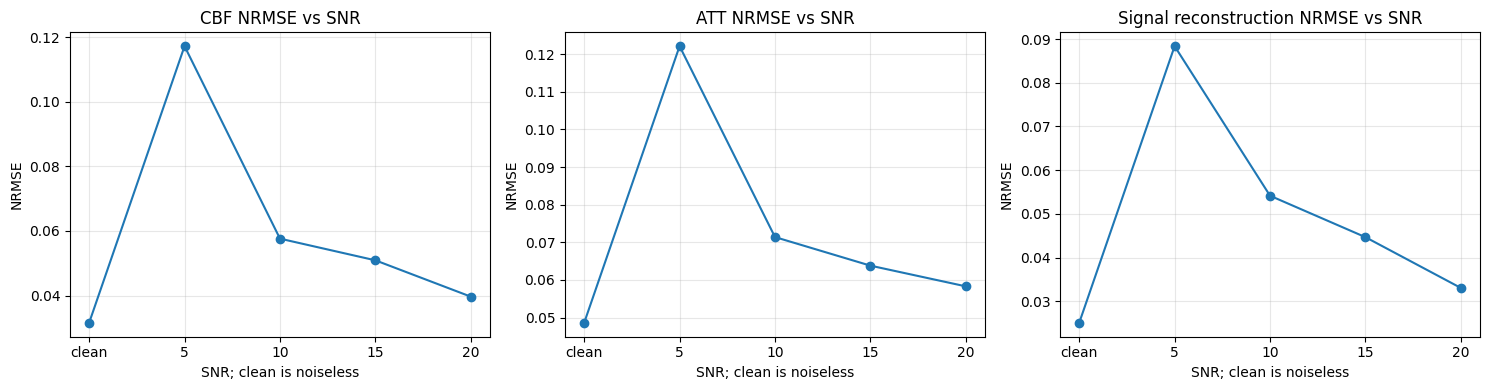

In [3]:
snr_labels = [str(row['snr']) for row in report['synthetic']]
cbf_nrmse = [row['cbf_nrmse'] for row in report['synthetic']]
att_nrmse = [row['att_nrmse'] for row in report['synthetic']]
signal_nrmse = [row['signal_nrmse'] for row in report['synthetic']]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(snr_labels, cbf_nrmse, marker='o')
axes[0].set_title('CBF NRMSE vs SNR')
axes[1].plot(snr_labels, att_nrmse, marker='o')
axes[1].set_title('ATT NRMSE vs SNR')
axes[2].plot(snr_labels, signal_nrmse, marker='o')
axes[2].set_title('Signal reconstruction NRMSE vs SNR')
for axis in axes:
    axis.set_xlabel('SNR; clean is noiseless')
    axis.set_ylabel('NRMSE')
    axis.grid(True, alpha=0.3)
plt.tight_layout()
plot_path = OUTPUT_ROOT / 'synthetic_validation_metrics.png'
fig.savefig(plot_path, dpi=150)
print('Saved plot:', plot_path)

In [4]:
clinical = report['clinical']
print('CLINICAL DIAGNOSTICS')
print('Status:', clinical['status'])
print('Valid voxels:', clinical.get('valid_voxels'))
print('M0 statistics:', clinical.get('m0_statistics'))
print('Observed delta statistics:', clinical.get('observed_delta_statistics'))
print('Scaled signal statistics:', clinical.get('scaled_signal_statistics'))
print('Message:', clinical.get('message'))
print('Clinical maps saved: NO, because PLD/LD acquisition order is ambiguous.')
print('Summary path:', summary_path)

CLINICAL DIAGNOSTICS
Status: AMBIGUOUS_ACQUISITION_ORDER
Valid voxels: 211458
M0 statistics: {'min': 327.5, 'mean': 1513.4156494140625, 'max': 3831.75}
Observed delta statistics: {'min': -129.0, 'mean': 274.2619934082031, 'max': 2284.0}
Scaled signal statistics: [{'pld_position': 1, 'min': -7.077297210693359, 'mean': 239.15667724609375, 'max': 1197.3284912109375}, {'pld_position': 2, 'min': 5.025125503540039, 'mean': 185.72145080566406, 'max': 816.1764526367188}, {'pld_position': 3, 'min': -130.29771423339844, 'mean': 207.01171875, 'max': 2969.48193359375}, {'pld_position': 4, 'min': -22.7882022857666, 'mean': 152.6959228515625, 'max': 683.2971801757812}]
Message: Filenames do not encode the training PLD/LD table [0.700,2.033,3.366,0.700]/[1.333,1.333,1.333,4.000]; clinical maps were not inferred.
Clinical maps saved: NO, because PLD/LD acquisition order is ambiguous.
Summary path: D:\reinforcement learning\asl-github-repo\rl_inference_output\inference_summary.json


Saved plot: D:\reinforcement learning\asl-github-repo\rl_inference_output\true_vs_predicted_parameters.png
Saved plot: D:\reinforcement learning\asl-github-repo\rl_inference_output\representative_trajectories.png
Saved trajectories: D:\reinforcement learning\asl-github-repo\rl_inference_output\synthetic_trajectories.json


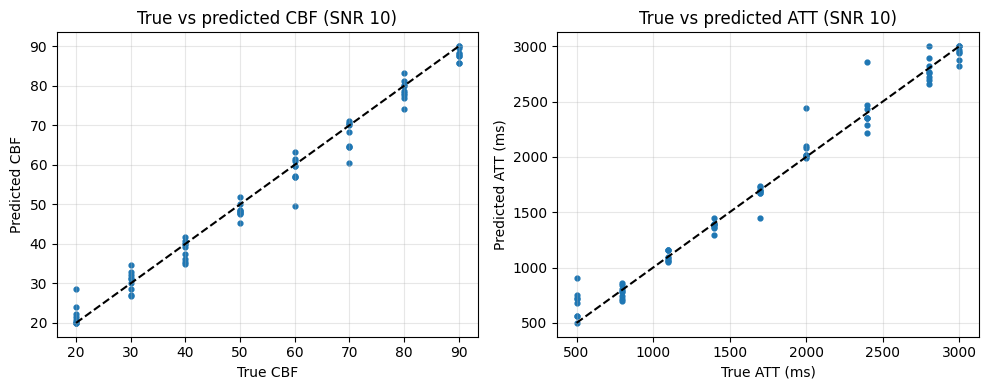

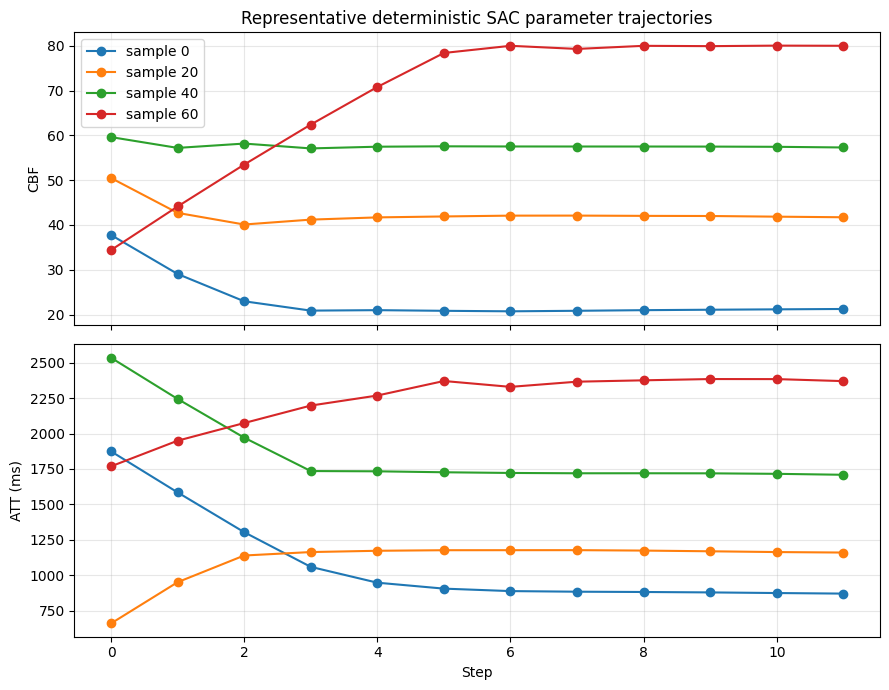

In [5]:
comparison = report['comparison_snr_10']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(comparison['true_cbf'], comparison['pred_cbf'], s=12)
axes[0].plot([20, 90], [20, 90], 'k--')
axes[0].set_title('True vs predicted CBF (SNR 10)')
axes[0].set_xlabel('True CBF')
axes[0].set_ylabel('Predicted CBF')
axes[1].scatter(comparison['true_att'], comparison['pred_att'], s=12)
axes[1].plot([500, 3000], [500, 3000], 'k--')
axes[1].set_title('True vs predicted ATT (SNR 10)')
axes[1].set_xlabel('True ATT (ms)')
axes[1].set_ylabel('Predicted ATT (ms)')
for axis in axes:
    axis.grid(True, alpha=0.3)
plt.tight_layout()
comparison_path = OUTPUT_ROOT / 'true_vs_predicted_parameters.png'
fig.savefig(comparison_path, dpi=150)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for sample in report['trajectories']:
    steps = sample['steps']
    x = [row['step'] for row in steps]
    axes[0].plot(x, [row['cbf'] for row in steps], marker='o', label=f"sample {sample['sample_index']}")
    axes[1].plot(x, [row['att'] for row in steps], marker='o', label=f"sample {sample['sample_index']}")
axes[0].set_ylabel('CBF')
axes[1].set_ylabel('ATT (ms)')
axes[1].set_xlabel('Step')
axes[0].set_title('Representative deterministic SAC parameter trajectories')
axes[0].legend()
for axis in axes:
    axis.grid(True, alpha=0.3)
plt.tight_layout()
trajectory_path = OUTPUT_ROOT / 'representative_trajectories.png'
fig.savefig(trajectory_path, dpi=150)
print('Saved plot:', comparison_path)
print('Saved plot:', trajectory_path)
print('Saved trajectories:', OUTPUT_ROOT / 'synthetic_trajectories.json')